<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/NLPNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import pandas as pd
import zipfile
import io
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))

df = pd.read_csv(z.open('SMSSpamCollection'),
                 sep='\t', names=['label','message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
len(df)

5572

In [4]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [7]:
df['msg length'] = df['message'].apply(len)

df.head()

,label,message,msg length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


<Axes: ylabel='Frequency'>

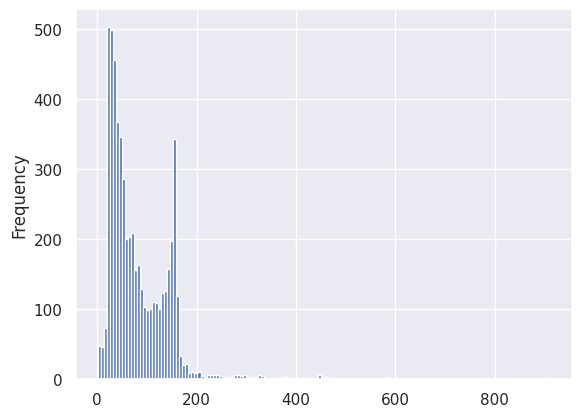

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

df['msg length'].plot.hist(bins=150)

In [9]:
df['msg length'].describe()

,msg length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


In [10]:
df[df['msg length'] == 910]['message'].iloc[0] # im cryin rn

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

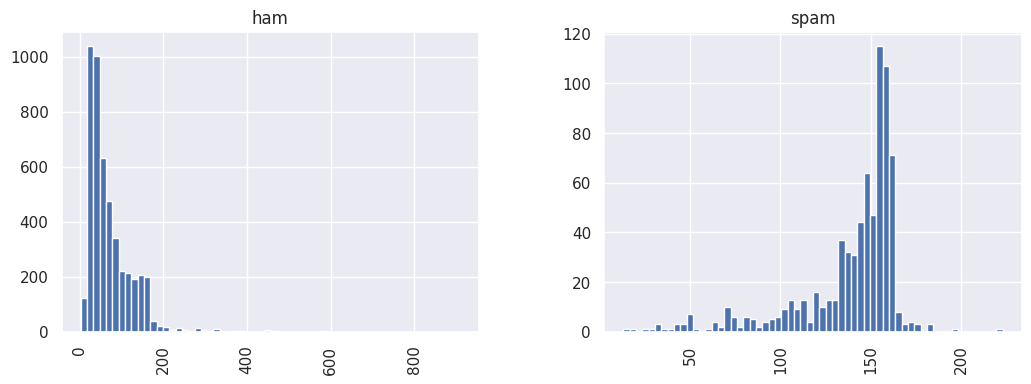

In [11]:
df.hist(column='msg length', by='label', bins=60, figsize=(12, 4))

In [12]:
import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [13]:
msg = 'Sample message. Some stuff!'

no_punc_msg = [c for c in msg if c not in string.punctuation]

no_punc_msg

['S',
 'a',
 'm',
 'p',
 'l',
 'e',
 ' ',
 'm',
 'e',
 's',
 's',
 'a',
 'g',
 'e',
 ' ',
 'S',
 'o',
 'm',
 'e',
 ' ',
 's',
 't',
 'u',
 'f',
 'f']

In [14]:
from nltk.corpus import stopwords

stopwords.words('english')[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [15]:
no_punc_msg = ''.join(no_punc_msg)

no_punc_msg

'Sample message Some stuff'

In [16]:
clean_msg = [word for word in no_punc_msg.split() if word.lower() not in stopwords.words('english')]

clean_msg

['Sample', 'message', 'stuff']

In [17]:
def clean_msg(msg):
  no_punc_msg = [c for c in msg if c not in string.punctuation]
  no_punc_msg = ''.join(no_punc_msg)
  return [word for word in no_punc_msg.split() if word.lower() not in stopwords.words('english')]

In [18]:
df['message'].apply(clean_msg).head(3)

,message
0,"[Go, jurong, point, crazy, Available, bugis, n..."
1,"[Ok, lar, Joking, wif, u, oni]"
2,"[Free, entry, 2, wkly, comp, win, FA, Cup, fin..."


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

bow_transformer = CountVectorizer(analyzer=clean_msg).fit(df['message'])

In [20]:
len(bow_transformer.vocabulary_)

11425

In [21]:
df['message'][24], print(bow_transformer.transform([df['message'][24]]))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 1053)	1
  (0, 1905)	1
  (0, 8092)	1
  (0, 9932)	1
  (0, 10979)	1


('Ffffffffff. Alright no way I can meet up with you sooner?', None)

In [22]:
bow_transformer.transform([df['message'][24]]).shape

(1, 11425)

In [23]:
bow_transformer.get_feature_names_out()[1053]

'Alright'

In [24]:
df_bow = bow_transformer.transform(df['message'])

In [25]:
df_bow.shape

(5572, 11425)

In [26]:
df_bow.nnz # non zero occurences

50548

In [27]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer().fit(df_bow)

In [28]:
tfidf_transformer.idf_[bow_transformer.vocabulary_['hello']]

np.float64(7.8339293183414815)

In [29]:
df_tfidf = tfidf_transformer.transform(df_bow)

In [30]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=clean_msg)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function clean_msg at 0x7b5a105c22a0>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [31]:
predictions = pipeline.predict(X_test)

In [32]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print(classification_report(y_test, predictions))

accuracy_score(y_test, predictions)

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1593
        spam       1.00      0.74      0.85       246

    accuracy                           0.96      1839
   macro avg       0.98      0.87      0.91      1839
weighted avg       0.97      0.96      0.96      1839



array([[1593,    0],
       [  65,  181]])

In [33]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/yelp.csv"
df = pd.read_csv(url)
df.head(1)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [35]:
df.describe()

,stars,cool,useful,funny
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.777500,0.876800,1.409300,0.701300
std,1.214636,2.067861,2.336647,1.907942
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000
75%,5.000000,1.000000,2.000000,1.000000
max,5.000000,77.000000,76.000000,57.000000


In [36]:
df['text length'] = df['text'].apply(len)

df.head(1)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,text length
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889


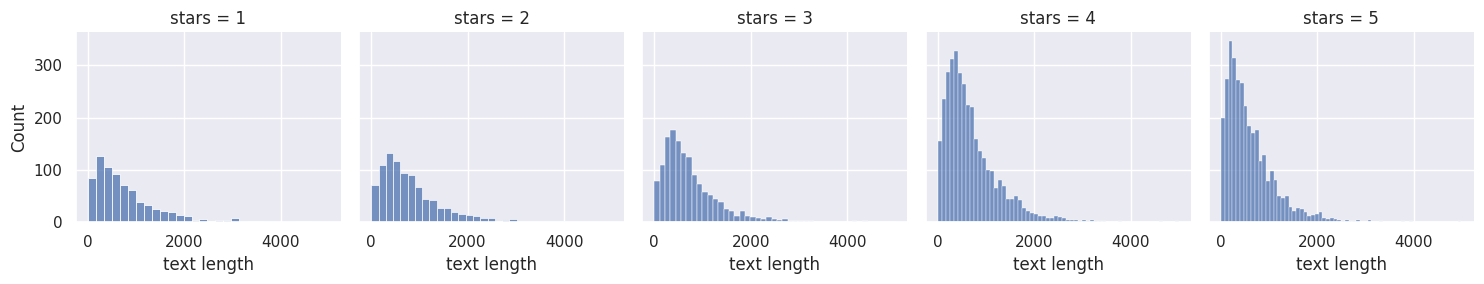

In [37]:
sns.FacetGrid(data=df, col='stars').map(sns.histplot, 'text length')

<Axes: xlabel='stars', ylabel='text length'>

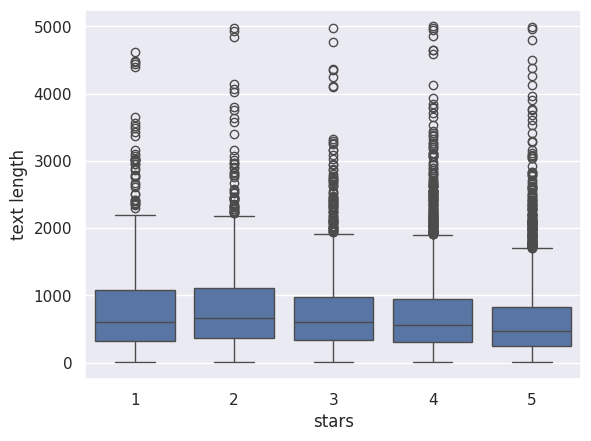

In [38]:
sns.boxplot(x=df['stars'], y=df['text length'])

<Axes: xlabel='stars', ylabel='count'>

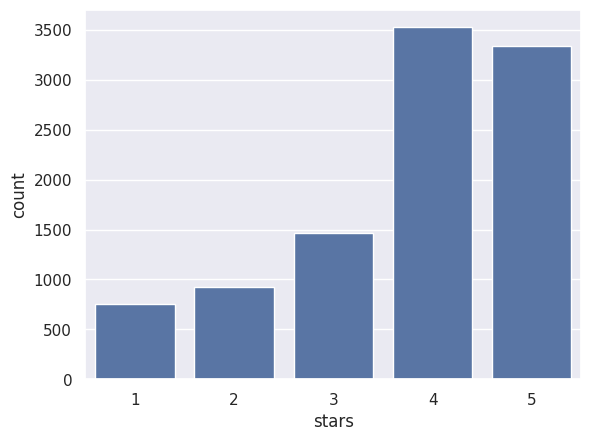

In [39]:
sns.countplot(x=df['stars'])

In [40]:
df.groupby('stars').mean(numeric_only=True)

,cool,useful,funny,text length
stars,,,,
1,0.576769,1.604806,1.056075,826.515354
2,0.719525,1.563107,0.875944,842.256742
3,0.788501,1.306639,0.694730,758.498289
4,0.954623,1.395916,0.670448,712.923142
5,0.944261,1.381780,0.608631,624.999101


In [41]:
df.groupby('stars').mean(numeric_only=True).corr(numeric_only=True)

,cool,useful,funny,text length
cool,1.000000,-0.743329,-0.944939,-0.857664
useful,-0.743329,1.000000,0.894506,0.699881
funny,-0.944939,0.894506,1.000000,0.843461
text length,-0.857664,0.699881,0.843461,1.000000


<Axes: >

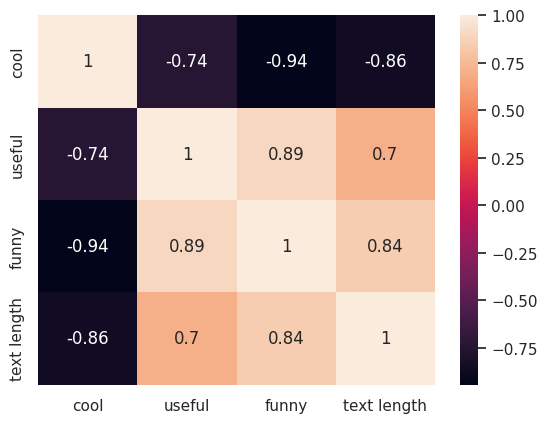

In [42]:
sns.heatmap(df.groupby('stars').mean(numeric_only=True).corr(numeric_only=True), annot=True)

In [43]:
df = df[(df['stars']==1) | (df['stars']==5)]

X = df['text']
y = df['stars']

cv = CountVectorizer()

X = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

nb = MultinomialNB()

nb.fit(X_train, y_train)

predictions = nb.predict(X_test)

print(classification_report(y_test, predictions))

accuracy_score(y_test, predictions)

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           1       0.84      0.62      0.71       261
           5       0.92      0.97      0.94      1088

    accuracy                           0.90      1349
   macro avg       0.88      0.80      0.83      1349
weighted avg       0.90      0.90      0.90      1349



array([[ 163,   98],
       [  32, 1056]])

In [44]:
pipeline = Pipeline([
    ('bow', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', MultinomialNB())
])

X = df['text']
y = df['stars']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print(classification_report(y_test, predictions))

accuracy_score(y_test, predictions)

confusion_matrix(y_test, predictions)

              precision    recall  f1-score   support

           1       1.00      0.00      0.01       261
           5       0.81      1.00      0.89      1088

    accuracy                           0.81      1349
   macro avg       0.90      0.50      0.45      1349
weighted avg       0.84      0.81      0.72      1349



array([[   1,  260],
       [   0, 1088]])